In [ ]:
import numpy as np
import pandas as pd
import kagglehub as kh

In [ ]:
# Download latest version
path = kh.dataset_download("serkantysz/550k-spotify-songs-audio-lyrics-and-genres")

print("Path to dataset files:", path)

100%|██████████| 235M/235M [00:02<00:00, 102MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres/versions/1


In [ ]:
import os
import pandas as pd

path = '/root/.cache/kagglehub/datasets/serkantysz/550k-spotify-songs-audio-lyrics-and-genres/versions/1'
# Load both datasets directly
dfA = pd.read_csv(os.path.join(path, 'artists.csv'))
dfS = pd.read_csv(os.path.join(path, 'songs.csv'))

print("Artists Data:")
display(dfA.head())
print("\nSongs Data:")
display(dfS.head())

Artists Data:


,id,name,followers,popularity,genres,main_genre
0,6YROFUbu5zRCHi2xkir5pk,Brian Hyland,67223,47,[],Pop
1,5tFRohaO5yEsuJxmMnlCO9,Barns Courtney,602647,62,[],Electronic
2,3w1Q754jb31h5CXQCcnLNL,Capcom Sound Team,210392,58,"['japanese vgm', 'soundtrack']",Electronic
3,3oDbviiivRWhXwIE8hxkVV,The Beach Boys,5139194,76,['baroque pop'],Classical
4,60zvRmhQHRxokEB1taAVpN,Beth Malone,1569,29,['musicals'],Classical



Songs Data:


,id,name,album_name,artists,danceability,energy,key,loudness,mode,speechiness,...,tempo,duration_ms,lyrics,year,genre,popularity,total_artist_followers,avg_artist_popularity,artist_ids,niche_genres
0,0Prct5TDjAnEgIqbxcldY9,!,UNDEN!ABLE,"[""HELLYEAH""]",0.415,0.605,7,-11.157,1,0.0575,...,100.059,79500,"He said he came from Jamaica,\nhe owned a coup...",2016,Rock,0,769490,52.0,"[""4hxDvVq5t8ebPYPdBl1F9f""]","[""groove metal"", ""metal""]"
1,2ASl4wirkeYm3OWZxXKYuq,!!,Childhood Dreams,"[""Yxngxr1""]",0.788,0.648,7,-9.135,0,0.3150,...,79.998,114000,"Fuck the bitch, now she running with my kids\n...",2019,Hip-Hop,29,143628,45.0,"[""2jwRHcdgkRhelYEMqndDKe""]",[]
2,5tA3ImW310llKo8EMBj2Ga,!!Noble Stabbings!!,Situationist Comedy,"[""Dillinger Four""]",0.171,0.957,2,-5.749,1,0.1490,...,175.317,197400,You like to stand on the other side\nPoint and...,2002,Rock,0,36619,35.0,"[""4YAN46l70QV0PGXlMg0iHi""]","[""melodic hardcore"", ""pop punk"", ""punk"", ""skat..."
3,0fROT4kK5oTm8xO8PX6EJF,!I'll Be Back!,!I'll Be Back!,"[""Ril\u00e8s""]",0.823,0.612,1,-7.767,1,0.2480,...,142.959,178533,"It's been a while, shit, I missed the rehab, p...",2018,Hip-Hop,43,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"
4,1xBFhv5faebv3mmwxx7DnS,!Lost!,!Lost!,"[""Ril\u00e8s""]",0.729,0.552,7,-8.562,0,0.0650,...,86.103,186197,I would like to give you all my time\nI would ...,2018,Hip-Hop,0,929303,63.0,"[""6pdcQa7by8IKuoVXvgknlI""]","[""french rap""]"


In [ ]:
dfS.columns

Index(['id', 'name', 'album_name', 'artists', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms', 'lyrics', 'year',
       'genre', 'popularity', 'total_artist_followers',
       'avg_artist_popularity', 'artist_ids', 'niche_genres'],
      dtype='object')

# What are we looking for?

1. Predict song genre/sub-genre from audio features

2. predict popularity from audio + artist metrics + lyrics


3. how to make a "hit song" based off of features


4. content based recommendation system



✦ Supervised Learning (Labeled Data)
  In Supervised Learning, the model learns from input-output pairs. You provide the "answer key" during training.


  1. Regression (Continuous Outputs)
   * Popularity Forecasting: Predict the exact popularity score (0-100) based on energy, tempo, and loudness.
   * Release Year Estimation: Predict the year a song was released based on its "sonic signature" (e.g., 80s gated
     reverb vs. modern compression).
   * Streaming Count Prediction: Estimating total plays based on artist followers and initial 24-hour performance.


  2. Classification (Discrete Categories)
   * Genre Labeling: Predict if a song belongs to Rock, Pop, or Hip-Hop using audio features.
   * Explicit Content Filter: A binary classifier (0 or 1) that analyzes lyrics to determine if a song should be
     marked "Explicit."
   * Mood Classification: Categorizing songs into "Happy," "Sad," "Angry," or "Chill" based on valence and energy
     levels.
   * Hit/Flop Prediction: A binary classifier that predicts if a song will reach the Top 50 based on early metrics.

  ---


  Unsupervised Learning (Unlabeled Data)
  In Unsupervised Learning, the model identifies hidden patterns or structures in the data without being told what
  the "correct" output is.


  1. Clustering (Grouping)
   * Micro-Genre Discovery: Using K-Means to group songs into 50+ hyper-specific clusters (e.g., "Dark Lo-fi
     Hip-Hop") that don't exist in the standard genre column.
   * Artist Segmenting: Grouping artists based on their followers vs. popularity to identify "Underground Gems,"
     "Rising Stars," and "Mainstream Giants."
   * User Persona Mapping: Clustering users based on their listening history to define distinct "Listener Profiles"
     (e.g., "The Gym Motivator," "The Deep Work Coder").


  2. Association Rules (Relationships)
   * Market Basket Analysis: If a user likes Artist A, they have an 85% probability of liking Artist B. This is the
     foundation of "Fans also like" sections.
   * Sequential Pattern Mining: Identifying that users who listen to Lo-fi Beats in the morning often switch to
     Synthwave in the evening.


  3. Dimensionality Reduction (Simplification)
   * Visualization: Using PCA (Principal Component Analysis) or t-SNE to squash 20+ audio features into a 2D or 3D
     map. This allows you to "see" the distance between musical styles.
   * Noise Reduction: Removing redundant features that are highly correlated (like loudness and energy) to make
     models faster and more accurate.


  4. Anomaly Detection (Outlier Detection)
   * Identifying Non-Music: Automatically flagging white noise tracks, podcasts, or "joke" songs that deviate
     significantly from standard musical structures.
   * Bot Detection: Identifying artificial streaming patterns that don't match human listening behavior.


  For your project: You are combining Supervised Regression (Popularity) with Unsupervised Clustering
  (Hyper-specific playlists). This "Hybrid Approach" is exactly how modern recommendation engines like Spotify's
  Discover Weekly actually function.

**Genre prediction with supervised classification**

-using audio features to predict genre with logistic regression and random forest, evaluates both.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

Check how many genres there are

In [ ]:
print("Number of unique genres:", dfS['genre'].nunique())
print("\nGenres:")
print(dfS['genre'].value_counts())

Number of unique genres: 10

Genres:
genre
Rock          197168
Pop            72539
Electronic     69755
Folk           50843
Country        46076
Hip-Hop        41745
R&B            27337
Jazz           17010
Blues          15976
Classical      12173
Name: count, dtype: int64


Filter out Rock and anything before year 2000

In [ ]:
df_filtered = dfS[(dfS['year'] >= 2000) & (dfS['genre'] != 'Rock')].copy()

print("Filtered shape:", df_filtered.shape)
print("\nGenre counts after filtering:")
print(df_filtered['genre'].value_counts())
print("\nNumber of remaining genres:", df_filtered['genre'].nunique())

Filtered shape: (291292, 24)

Genre counts after filtering:
genre
Electronic    66523
Pop           58418
Folk          41779
Hip-Hop       37181
Country       35963
R&B           21707
Blues         11010
Classical      9396
Jazz           9315
Name: count, dtype: int64

Number of remaining genres: 9


Select features and targets

In [ ]:
audio_cols = [
    'danceability', 'energy', 'key', 'loudness', 'mode',
    'speechiness', 'acousticness', 'instrumentalness',
    'liveness', 'valence', 'tempo', 'duration_ms'
]

target_col = 'genre'

df_model = df_filtered[audio_cols + [target_col]].dropna().copy()

print("Modeling shape:", df_model.shape)
print(df_model['genre'].value_counts())

Modeling shape: (291292, 13)
genre
Electronic    66523
Pop           58418
Folk          41779
Hip-Hop       37181
Country       35963
R&B           21707
Blues         11010
Classical      9396
Jazz           9315
Name: count, dtype: int64


Balance genres by taking up to 5000 songs from each genre

In [ ]:
df_balanced = (
    df_model.groupby('genre', group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))
    .reset_index(drop=True)
)

print("Balanced shape:", df_balanced.shape)
print("\nBalanced genre counts:")
print(df_balanced['genre'].value_counts())

Balanced shape: (45000, 13)

Balanced genre counts:
genre
Blues         5000
Classical     5000
Country       5000
Electronic    5000
Folk          5000
Hip-Hop       5000
Jazz          5000
Pop           5000
R&B           5000
Name: count, dtype: int64


/tmp/ipykernel_15554/1125979118.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))


X and y train test split defitions

Train/test split

In [ ]:
from sklearn.model_selection import train_test_split

X = df_balanced[audio_cols]
y = df_balanced[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Train shape: (36000, 12) (36000,)
Test shape: (9000, 12) (9000,)


Logistic Regression Baseline

In [ ]:
log_reg_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=2000))
])

log_reg_model.fit(X_train, y_train)

y_pred_lr = log_reg_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.36088888888888887

Classification Report:

              precision    recall  f1-score   support

       Blues       0.28      0.23      0.25      1000
   Classical       0.37      0.40      0.38      1000
     Country       0.29      0.50      0.37      1000
  Electronic       0.46      0.61      0.52      1000
        Folk       0.14      0.02      0.03      1000
     Hip-Hop       0.55      0.65      0.60      1000
        Jazz       0.34      0.48      0.40      1000
         Pop       0.18      0.09      0.12      1000
         R&B       0.32      0.28      0.30      1000

    accuracy                           0.36      9000
   macro avg       0.33      0.36      0.33      9000
weighted avg       0.33      0.36      0.33      9000



Random Forest Model

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.4518888888888889

Random Forest Classification Report:

              precision    recall  f1-score   support

       Blues       0.43      0.42      0.43      1000
   Classical       0.48      0.47      0.48      1000
     Country       0.38      0.51      0.44      1000
  Electronic       0.58      0.66      0.62      1000
        Folk       0.35      0.14      0.21      1000
     Hip-Hop       0.58      0.71      0.64      1000
        Jazz       0.42      0.54      0.48      1000
         Pop       0.35      0.20      0.26      1000
         R&B       0.37      0.41      0.39      1000

    accuracy                           0.45      9000
   macro avg       0.44      0.45      0.44      9000
weighted avg       0.44      0.45      0.44      9000



In [ ]:
feature_importance = pd.DataFrame({
    'Feature': audio_cols,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
5,speechiness,0.135276
0,danceability,0.109226
6,acousticness,0.106976
1,energy,0.100082
9,valence,0.094749
7,instrumentalness,0.086534
11,duration_ms,0.084853
10,tempo,0.081647
3,loudness,0.078310
8,liveness,0.065992


In [ ]:
from sklearn.metrics import accuracy_score, f1_score

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Macro F1": [
        f1_score(y_test, y_pred_lr, average='macro'),
        f1_score(y_test, y_pred_rf, average='macro')
    ],
    "Weighted F1": [
        f1_score(y_test, y_pred_lr, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted')
    ]
})

results

,Model,Accuracy,Macro F1,Weighted F1
0,Logistic Regression,0.360889,0.329979,0.329979
1,Random Forest,0.451889,0.435858,0.435858


The Random Forest model performed better than Logistic Regression for predicting broad song genre from audio features. On the sampled dataset, Random Forest achieved 45.18% accuracy compared with 36.08% for Logistic Regression. This indicates that genre is related to audio features in a non-linear way, and that tree-based models are better able to capture those relationships. Hip-gop and Electronic were among the easiest genres for both models to recognize, especially with Random Forest. Jaz and Classical were also fairly distinguisable. Folk and Pop were harder to classify, which means tha their audio patterns most likely overlaps more with other genres. Country had decel recall, meaning hte models often found Country songs evei if sometimes they confused other songs as Country. Speechiness, danceability, acousticness, energy, and valence were the top 5 most useful features. Whereas key and mode were least useful.

Bar chart comparing model performance

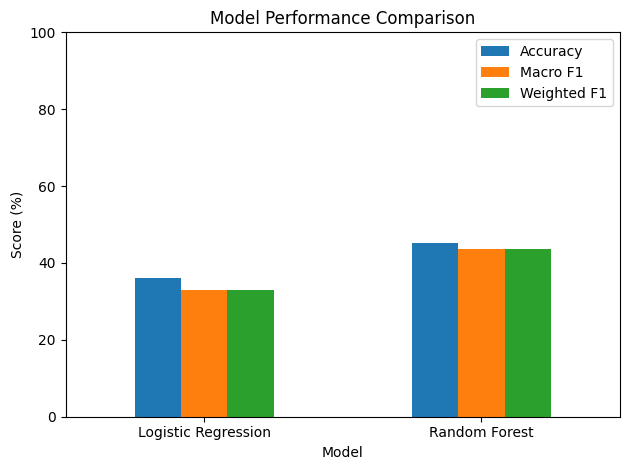

In [ ]:
import matplotlib.pyplot as plt

results_percent = results.copy()
results_percent[['Accuracy', 'Macro F1', 'Weighted F1']] = (
    results_percent[['Accuracy', 'Macro F1', 'Weighted F1']] * 100
)

ax = results_percent.plot(
    x='Model',
    y=['Accuracy', 'Macro F1', 'Weighted F1'],
    kind='bar'
)

plt.title('Model Performance Comparison')
plt.ylabel('Score (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

Feature importance plot

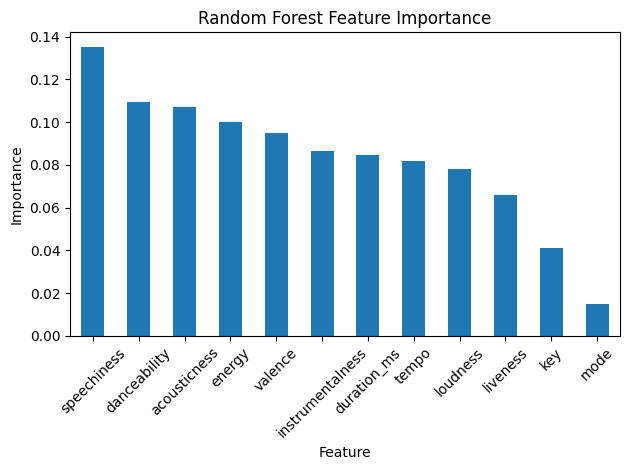

In [ ]:
feature_importance.plot(
    kind='bar',
    x='Feature',
    y='Importance',
    legend=False
)
plt.title('Random Forest Feature Importance')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Confusion Matrix

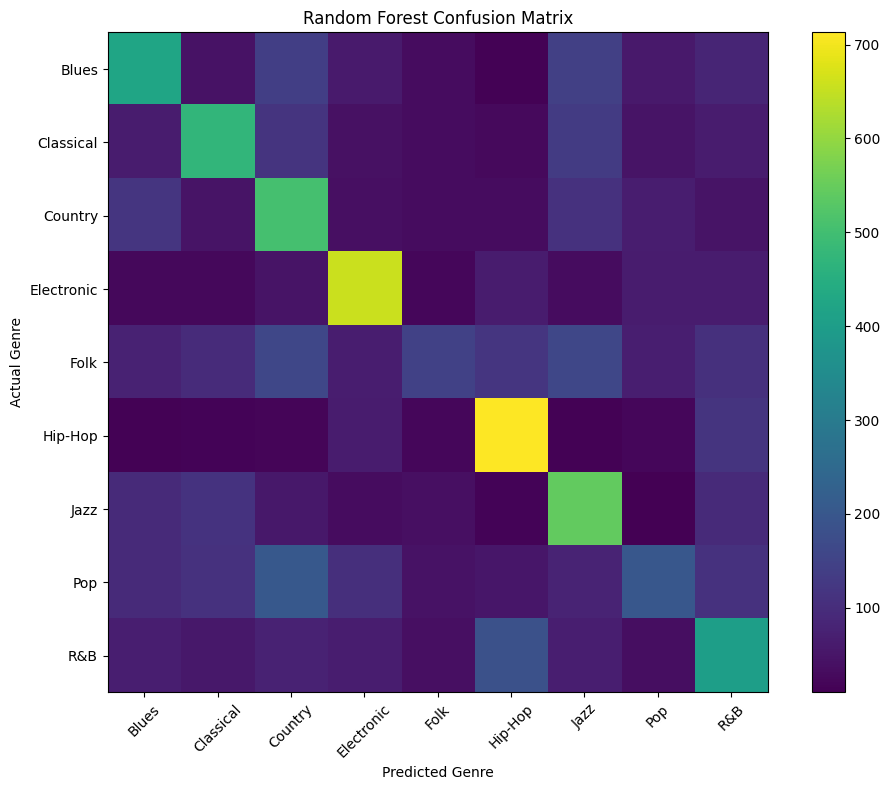

In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_rf, labels=rf_model.classes_)

plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title('Random Forest Confusion Matrix')
plt.colorbar()

plt.xticks(range(len(rf_model.classes_)), rf_model.classes_, rotation=45)
plt.yticks(range(len(rf_model.classes_)), rf_model.classes_)

plt.xlabel('Predicted Genre')
plt.ylabel('Actual Genre')
plt.tight_layout()
plt.show()

The above chart shows how model's predicted genres compare to the true genres. The rows are the actual genre, the columns are the predicted genre. Each square shows how many songs fell into that actual/predicted combination. Brighter squares mean more songs.

The diagonal from top left to bottom right show the songs the model got correct. Some Pop and Folk songs are being confused for Country, some R&B are being confused for Hip-Hop, etc.